In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Here we will be doing all the analyiss of the dataset and the model's performance and selecting the best model from each binary classifier and severity classifier


In [3]:
### Analyzing the dataset 

data = pd.read_csv('../Datasets/pre-processedData.csv')

data.head(5)




,Unnamed: 0,duration,src_bytes,dst_bytes,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_RSTO,flag_RSTR,flag_S1,flag_S3,flag_SF,flag_SH,is_malicious,Severity_Score,bytes_ratio,total_bytes
0,0,0.0,6.198479,0.000000,0.0,0.0,0.0,0.0,0,0.0,...,0,0,0,0,1,0,0,0,6.198479,6.198479
1,1,0.0,4.990433,0.000000,0.0,0.0,0.0,0.0,0,0.0,...,0,0,0,0,1,0,0,0,4.990433,4.990433
2,2,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0,0.0,...,0,0,0,0,0,0,1,2,0.000000,0.000000
3,3,0.0,5.451038,9.006264,0.0,0.0,0.0,0.0,1,0.0,...,0,0,0,0,1,0,0,0,0.544763,14.457302
4,4,0.0,5.298317,6.042633,0.0,0.0,0.0,0.0,1,0.0,...,0,0,0,0,1,0,0,0,0.752321,11.340950


---
### Total Normal vs Attacked Data count


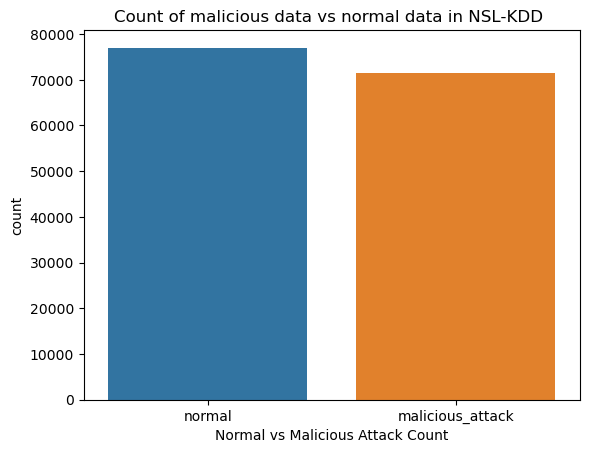

In [4]:
malicious_data_count = data['is_malicious'].map({0:'normal', 1:'malicious_attack'}).value_counts().reset_index()

sns.barplot(data = malicious_data_count, x = 'is_malicious', y = 'count',hue = 'is_malicious' )
plt.xlabel("Normal vs Malicious Attack Count")
plt.title("Count of malicious data vs normal data in NSL-KDD ")
plt.savefig('../Model Pictures/attackvsnormal.png')
plt.show()

### The attack types has been classified into normal and malicious. Malicious Attacks are further divided into three different types: 1. Low Severity, 2. Medium Severity, 3. High Severity 




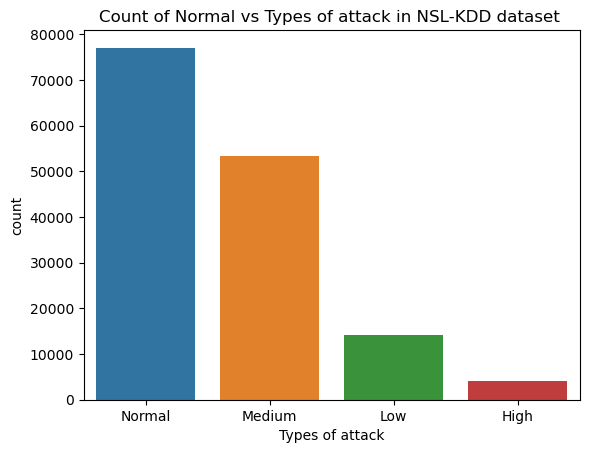

In [5]:
attack_data = pd.read_csv('../Datasets/final_dataset.csv')

severity_mapping = {
    # Level 0: Normal traffic
    'normal': 'Normal',
    
    # Level 1: LOW SEVERITY - Reconnaissance
    'ipsweep': 'Low',       # Network mapping
    'nmap': 'Low',          # Port scanning
    'portsweep': 'Low',     # Port scanning
    'satan': 'Low',         # Security scanner
    'mscan': 'Low',         # Mass scanner
    'saint': 'Low',         # Security scanner
    
    # Level 2: MEDIUM SEVERITY - Availability attacks
    'back': 'Medium',       # DoS
    'land': 'Medium',       # DoS
    'neptune': 'Medium',    # SYN flood
    'pod': 'Medium',        # Ping of death
    'smurf': 'Medium',      # ICMP flood
    'teardrop': 'Medium',   # DoS
    'apache2': 'Medium',    # DoS
    'udpstorm': 'Medium',   # DoS
    'processtable': 'Medium', # DoS
    'worm': 'Medium',      # Self-propagating
    'mailbomb': 'Medium',   # Email-based DoS
    # Level 3: HIGH SEVERITY - Unauthorized access
    'guess_passwd': 'High',     # Brute force
    'ftp_write': 'High',        # File upload
    'imap': 'High',             # Mail access
    'phf': 'High',              # CGI exploit
    'multihop': 'High',         # Multi-stage
    'warezmaster': 'High',      # Illegal software
    'warezclient': 'High',      # Illegal software client
    'spy': 'High',              # Spyware
    'xlock': 'High',            # Lockout attack
    'xsnoop': 'High',           # Snooping
    'snmpguess': 'High',        # SNMP brute force
    'snmpgetattack': 'High',    # SNMP exploit
    'httptunnel': 'High',       # Tunneling
    'sendmail': 'High',         # Mail exploit
    'named': 'High',            # DNS exploit
    'buffer_overflow': 'High',  # Memory corruption
    'loadmodule': 'High',       # Kernel module
    'perl': 'High',             # Script execution
    'rootkit': 'High',          # Rootkit
    'sqlattack': 'High',        # SQL injection
    'xterm': 'High',            # Remote terminal
    'ps': 'High'                # Process attack
}

types_of_attack = attack_data['attack'].map(severity_mapping)
attack_count = types_of_attack.value_counts().reset_index()


sns.barplot(x = 'attack', y = 'count', data = attack_count, hue = 'attack')
plt.xlabel("Types of attack")
plt.title("Count of Normal vs Types of attack in NSL-KDD dataset ")
plt.savefig('../Model Pictures/attackdistribution.png')
plt.show()

---
### Model's performance on analyzing the binary classification !

In [30]:
## Binary classification model's performance data 

data = pd.read_csv('../Datasets/models_performance.csv')
data.head(6)
data.drop(columns=['Unnamed: 0'], inplace = True)

data['precision'] = data['precision']* 100
data['recall'] = data['recall']* 100
data.head(5)

,models,precision,recall,f1_score,false_alarm,missed_attack_rate,roc_score
0,LR,95.969014,98.211028,0.970771,0.038058,0.017890,0.993120
1,SVM,95.916423,98.870492,0.973711,0.038835,0.011295,0.974935
2,GaussianNB,90.100694,92.907254,0.914825,0.094175,0.070927,0.955452
3,DecisionTrees,98.298200,98.470605,0.983843,0.015728,0.015294,0.984489
4,RandomTrees,98.915914,99.859689,0.993856,0.010097,0.001403,0.994250


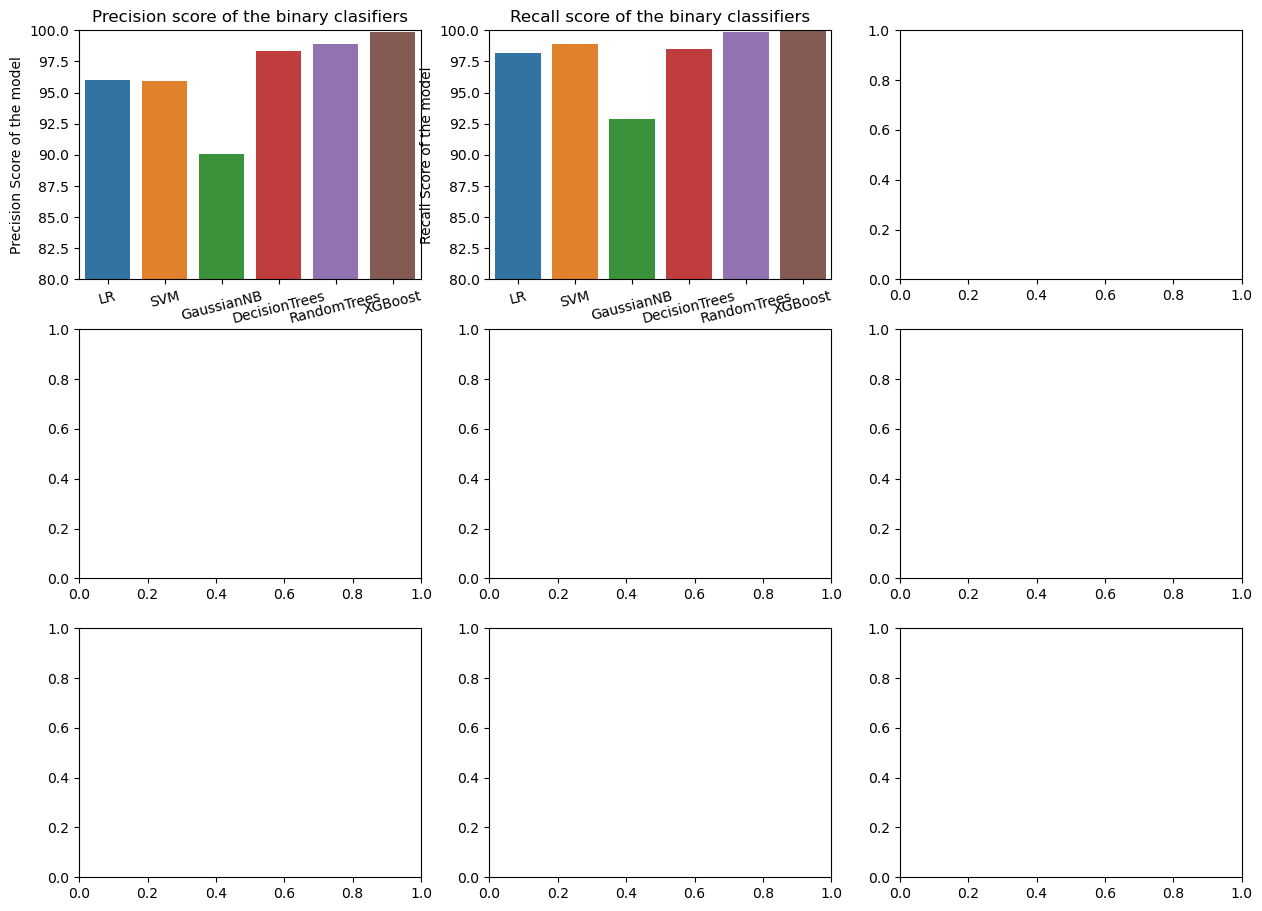

In [31]:
### Plotting the values 
fig,ax = plt.subplots(3,3, figsize = (15,11))

def plotting_the_datas(axes, x, y, data, xlabel, ylabel, ylim1,ylim2, title):
    sns.barplot(x = x, y =y , hue =x, ax = axes, data = data)
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_title(title)
    axes.set_ylim(ylim1,ylim2)
    axes.tick_params(axis='x', labelrotation=14)


plotting_the_datas(ax[0][0], 'models', 'precision',data, 'Models Trained and Tested', 'Precision Score of the model',80,100,'Precision score of the binary clasifiers')
plotting_the_datas(ax[0][1], 'models', 'recall',data, 'Models Trained and Tested', 'Recall Score of the model',80,100,'Recall score of the binary classifiers')



